## Report z analizy danych

In [20]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
flights = pd.read_csv("data/flights.csv")
airports = pd.read_csv("data/airports.csv")
airlines = pd.read_csv("data/airlines.csv")
planes = pd.read_csv("data/planes.csv")
weather = pd.read_csv("data/weather.csv")


# flights.head()
# airports.head()
# airlines.head()
# planes.head()
# weather.head()



## TEST BAZY DANYCH

In [21]:

print("--- 1. ŁADOWANIE DANYCH ---")
try:
    flights = pd.read_csv("data/flights.csv")
    airports = pd.read_csv("data/airports.csv")
    airlines = pd.read_csv("data/airlines.csv")
    planes = pd.read_csv("data/planes.csv")
    weather = pd.read_csv("data/weather.csv")
    print(" Wszystkie 5 plików załadowano pomyślnie z folderu 'data'!\n")
except FileNotFoundError as e:
    print(f" Błąd: Nie znaleziono pliku. Upewnij się, że masz folder 'data'. Szczegóły: {e}")
    exit()

print("--- 2. TESTOWANIE RELACJI (MERGE) ---")
poczatkowa_liczba_lotow = len(flights)
print(f"Baza wyjściowa: {poczatkowa_liczba_lotow} lotów.\n")

# TEST A: Loty + Linie lotnicze (Prosty klucz o tej samej nazwie)
print("Test A: Łączenie flights + airlines (po kluczu 'carrier')...")
airlines_clean = airlines.drop_duplicates(subset=['carrier'])
merged_airlines = flights.merge(airlines_clean, on='carrier', how='left')

if len(merged_airlines) == poczatkowa_liczba_lotow:
    print(" Sukces ,  Liczba wierszy się zgadza.")
    print(f"   Doklejono kolumnę z nazwą linii: 'name'")
else:
    print(" Błąd! Liczba wierszy uległa zmianie.")
print("-" * 40)

# TEST B: Loty + Lotniska docelowe (Różne nazwy kluczy)
print("Test B: Łączenie flights + airports (po 'dest' i 'faa')...")
airports_clean = airports.drop_duplicates(subset=['faa'])
merged_airports = flights.merge(airports_clean, left_on='dest', right_on='faa', how='left')

if len(merged_airports) == poczatkowa_liczba_lotow:
    print(" Sukces ,  Liczba wierszy się zgadza.")
    # dropujemy 'faa' bo to duplikat 'dest' po złączeniu
    merged_airports = merged_airports.drop(columns=['faa'])
    print(f"   Doklejono dane geograficzne lotnisk (lat, lon, alt itp.)")
else:
    print(" Błąd ,  Liczba wierszy uległa zmianie.")
print("-" * 40)

# TEST C: Loty + Samoloty (Prosty klucz o tej samej nazwie)
print("Test C: Łączenie flights + planes (po kluczu 'tailnum')...")
planes_clean = planes.drop_duplicates(subset=['tailnum'])
merged_planes = flights.merge(planes_clean, on='tailnum', how='left')

if len(merged_planes) == poczatkowa_liczba_lotow:
    print(" Sukces ,  Liczba wierszy się zgadza.")
    print(f"   Doklejono dane techniczne maszyn (silniki, producent itp.)")
else:
    print(" Błąd! Liczba wierszy uległa zmianie.")
print("-" * 40)

# TEST D: Loty + Pogoda (Łączenie po 5 kolumnach naraz)
print("Test D: Łączenie flights + weather (wielokrotny klucz)...")
klucze_pogody = ['origin', 'year', 'month', 'day', 'hour']
weather_clean = weather.drop_duplicates(subset=klucze_pogody)
merged_weather = flights.merge(weather_clean, on=klucze_pogody, how='left')

if len(merged_weather) == poczatkowa_liczba_lotow:
    print(" Sukces , Liczba wierszy się zgadza.")
    print(f"   Doklejono warunki meteo (temp, wind_speed, precip itp.)")
else:
    print(" Błąd , Liczba wierszy uległa zmianie.")
print("=" * 40)
print(" Skrypt zakończył działanie. Wszystko działa")

--- 1. ŁADOWANIE DANYCH ---
 Wszystkie 5 plików załadowano pomyślnie z folderu 'data'!

--- 2. TESTOWANIE RELACJI (MERGE) ---
Baza wyjściowa: 336776 lotów.

Test A: Łączenie flights + airlines (po kluczu 'carrier')...
 Sukces ,  Liczba wierszy się zgadza.
   Doklejono kolumnę z nazwą linii: 'name'
----------------------------------------
Test B: Łączenie flights + airports (po 'dest' i 'faa')...
 Sukces ,  Liczba wierszy się zgadza.
   Doklejono dane geograficzne lotnisk (lat, lon, alt itp.)
----------------------------------------
Test C: Łączenie flights + planes (po kluczu 'tailnum')...
 Sukces ,  Liczba wierszy się zgadza.
   Doklejono dane techniczne maszyn (silniki, producent itp.)
----------------------------------------
Test D: Łączenie flights + weather (wielokrotny klucz)...
 Sukces , Liczba wierszy się zgadza.
   Doklejono warunki meteo (temp, wind_speed, precip itp.)
 Skrypt zakończył działanie. Wszystko działa


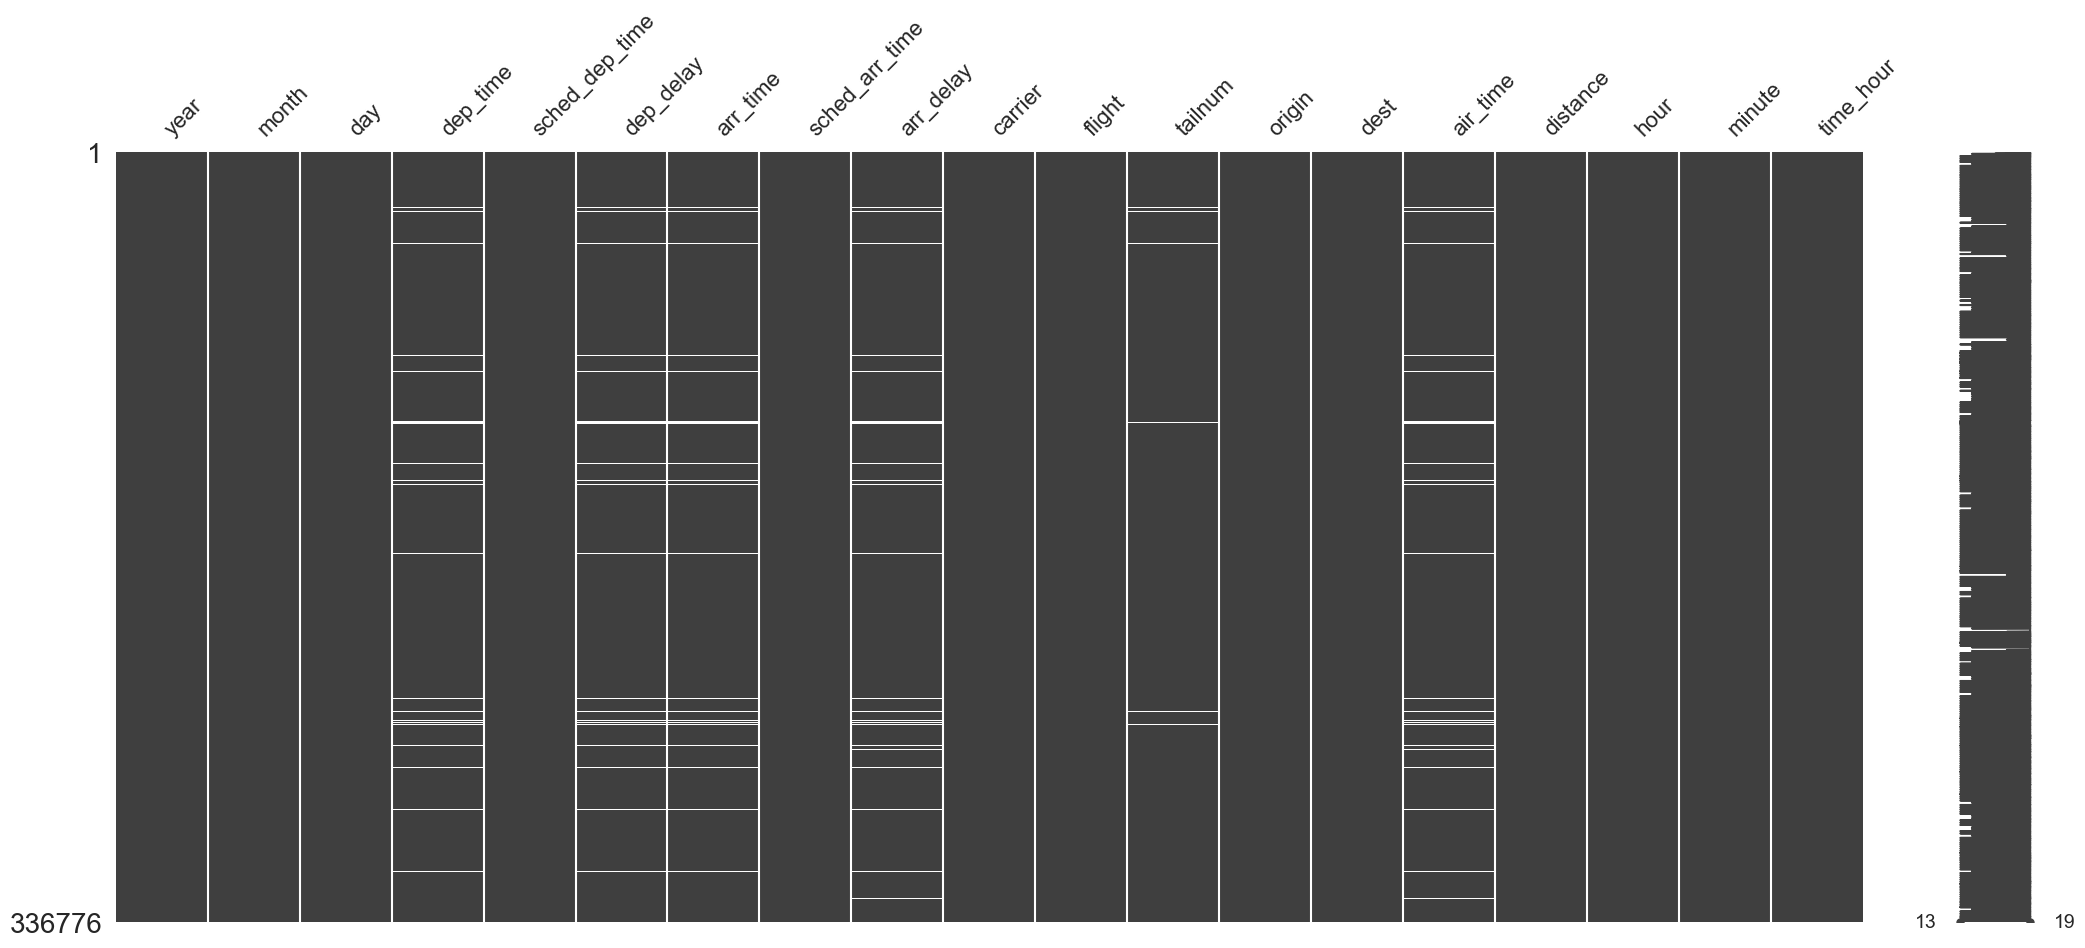

In [22]:
msno.matrix(flights);

 WERYFIKACJA DUPLIKATÓW: AIRLINES 
Brak zduplikowanych wierszy (całkowitych).
Klucz główny ['carrier'] jest w pełni unikalny.
--------------------------------------------------
 WERYFIKACJA DUPLIKATÓW: PLANES 
Brak zduplikowanych wierszy (całkowitych).
Klucz główny ['tailnum'] jest w pełni unikalny.
--------------------------------------------------
 WERYFIKACJA DUPLIKATÓW: WEATHER 
Brak zduplikowanych wierszy (całkowitych).
BŁĄD KRYTYCZNY: Znaleziono 3 powtórzeń w kluczu głównym ['origin', 'year', 'month', 'day', 'hour']!
--------------------------------------------------
Anomalie dla : Flights


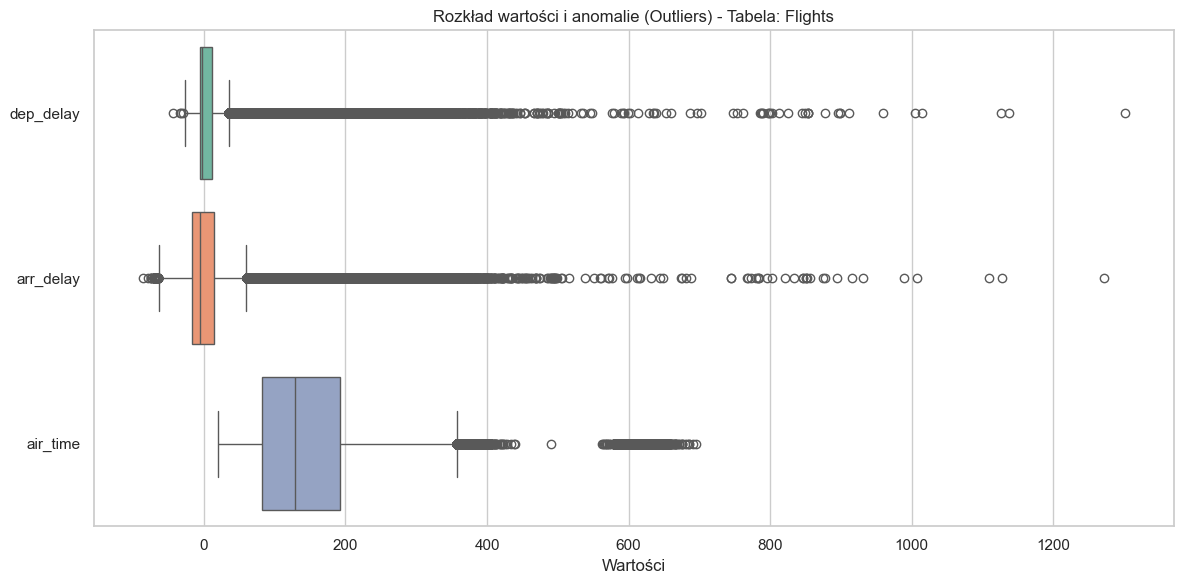

[FLIGHTS] Są braki 


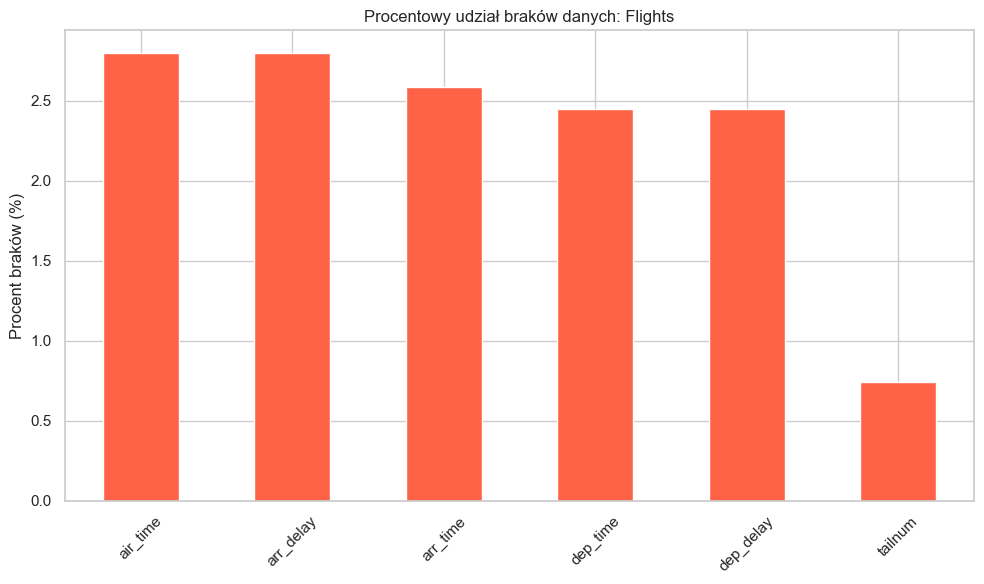

[AIRPORTS] Są braki 


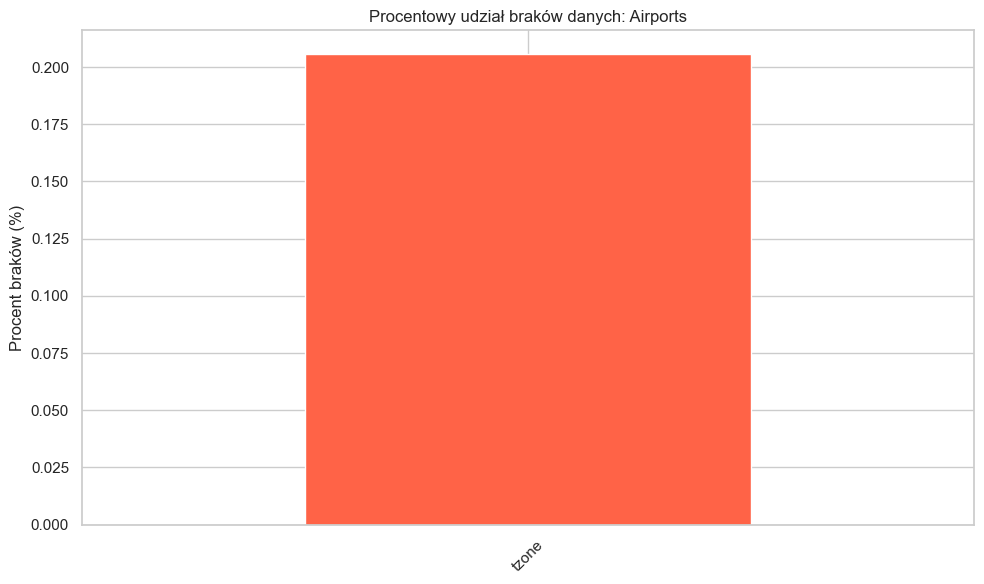

[AIRLINES] W tej tabeli nie ma NAN .
[PLANES] Są braki 


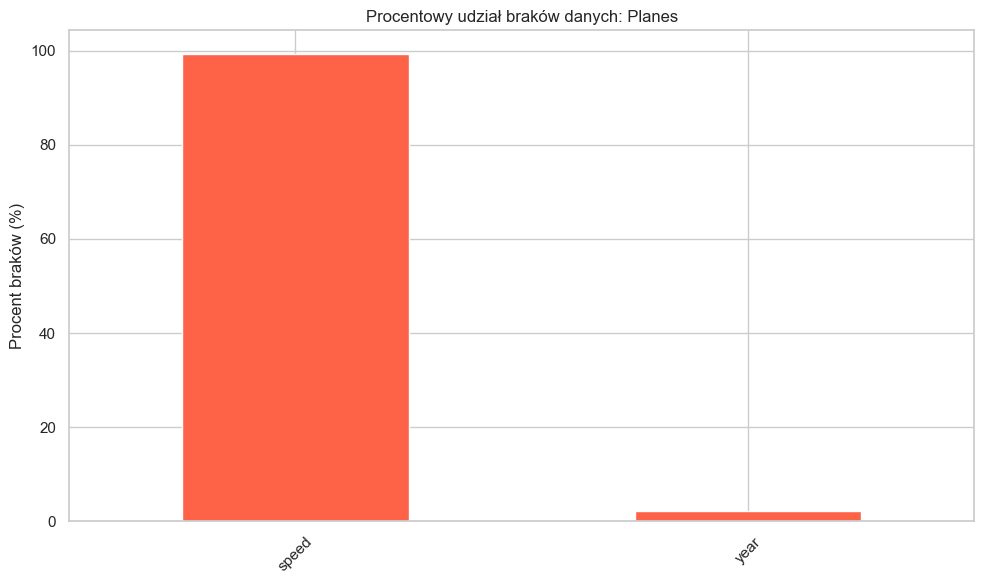

[WEATHER] Są braki 


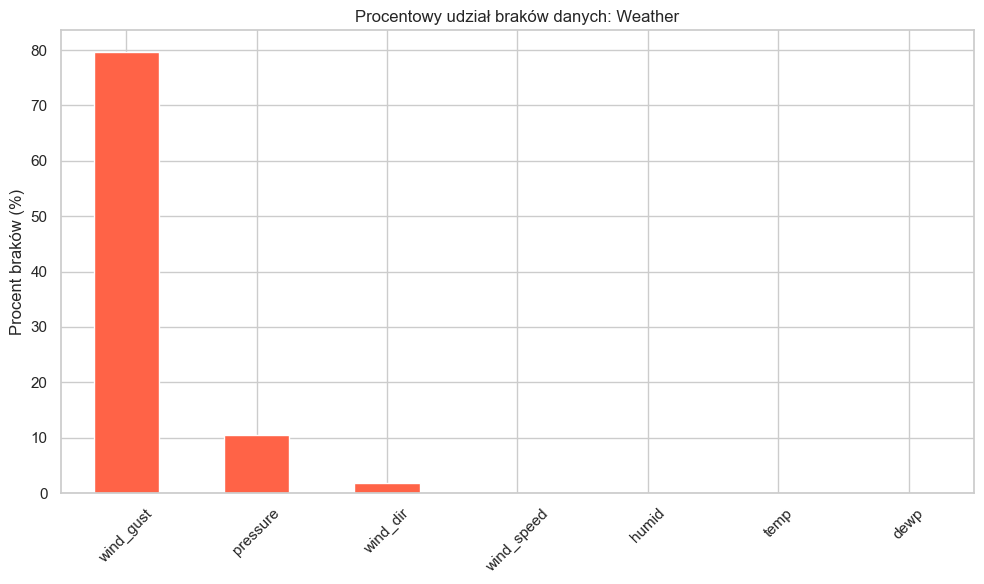

In [23]:
def sprawdz_duplikaty(df, nazwa_tabeli, klucz_glowny=None):
    """
    Sprawdza występowanie zduplikowanych wierszy w całej tabeli
    oraz opcjonalnie sprawdza unikalność wskazanego klucza głównego.
    """
    print(f" WERYFIKACJA DUPLIKATÓW: {nazwa_tabeli.upper()} ")

    # 1. Sprawdzanie duplikatów całych wierszy (identyczne wszystkie kolumny)
    duplikaty_wierszy = df.duplicated().sum()
    if duplikaty_wierszy > 0:
        print(f"OSTRZEŻENIE: Znaleziono {duplikaty_wierszy} w 100% zduplikowanych wierszy.")
    else:
        print("Brak zduplikowanych wierszy (całkowitych).")

    # 2. Sprawdzanie duplikatów w kluczu głównym (jeśli został podany)
    if klucz_glowny:
        # Obsługa kluczy złożonych (lista) lub pojedynczych (string)
        if isinstance(klucz_glowny, str):
            klucz_glowny = [klucz_glowny]

        duplikaty_klucza = df.duplicated(subset=klucz_glowny).sum()
        if duplikaty_klucza > 0:
            print(f"BŁĄD KRYTYCZNY: Znaleziono {duplikaty_klucza} powtórzeń w kluczu głównym {klucz_glowny}!")
        else:
            print(f"Klucz główny {klucz_glowny} jest w pełni unikalny.")
    print("-" * 50)


def wizualizuj_anomalie(df, nazwa_tabeli, kolumny_do_sprawdzenia):
    """
    Generuje wykresy pudełkowe (boxplots) dla wskazanych kolumn numerycznych,
    aby uwidocznić wartości odstające i błędy w danych.
    """
    print(f"Anomalie dla : {nazwa_tabeli}")

    kolumny_istniejace = [kol for kol in kolumny_do_sprawdzenia if kol in df.columns]
    if not kolumny_istniejace:
        print("Żadna ze wskazanych kolumn nie istnieje w tej tabeli.")
        return

    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")


    sns.boxplot(data=df[kolumny_istniejace], orient="h", palette="Set2")

    plt.title(f"Rozkład wartości i anomalie (Outliers) - Tabela: {nazwa_tabeli}")
    plt.xlabel("Wartości")
    plt.tight_layout()
    plt.show()

def sprawdz_i_rysuj(df, nazwa_tabeli):
    braki_procent = df.isna().mean() * 100
    braki_procent = braki_procent[braki_procent > 0].sort_values(ascending=False)
    if braki_procent.empty:
        print(f"[{nazwa_tabeli.upper()}] W tej tabeli nie ma NAN .")
        return


    print(f"[{nazwa_tabeli.upper()}] Są braki ")
    plt.figure(figsize=(10, 6))
    braki_procent.plot(kind='bar', color='tomato')
    plt.title(f"Procentowy udział braków danych: {nazwa_tabeli}")
    plt.ylabel("Procent braków (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
tabele_do_sprawdzenia = [
    (flights, "Flights"),
    (airports, "Airports"),
    (airlines, "Airlines"),
    (planes, "Planes"),
    (weather, "Weather")
]
sprawdz_duplikaty(airlines, "Airlines", klucz_glowny="carrier")
sprawdz_duplikaty(planes, "Planes", klucz_glowny="tailnum")
sprawdz_duplikaty(weather, "Weather", klucz_glowny=['origin', 'year', 'month', 'day', 'hour'])
wizualizuj_anomalie(flights, "Flights", ['dep_delay', 'arr_delay', 'air_time'])
for df, nazwa in tabele_do_sprawdzenia:
    sprawdz_i_rysuj(df, nazwa)

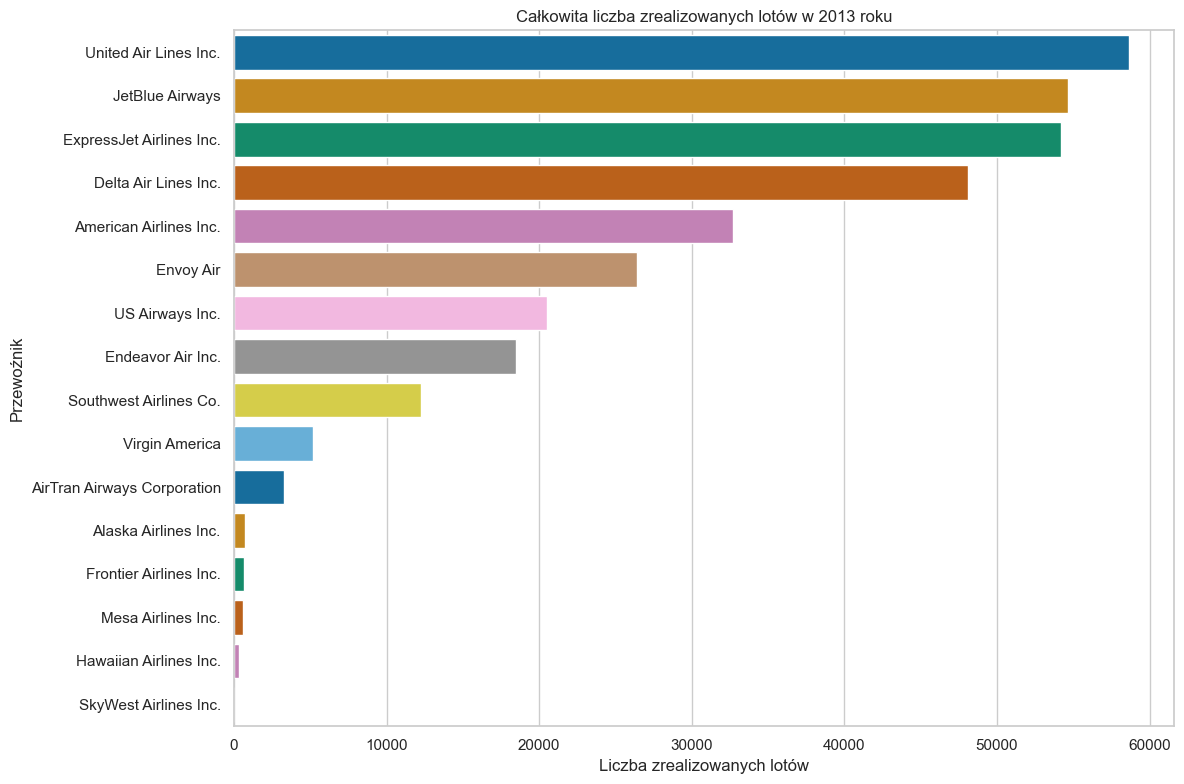

In [28]:
df = flights.merge(airlines.drop_duplicates(subset=['carrier']), on='carrier', how='left')

liczba_lotow = df['name'].value_counts().reset_index()
liczba_lotow.columns = ['Linia lotnicza', 'Liczba lotów']

# Konfiguracja i generowanie wykresu
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=liczba_lotow,
    x='Liczba lotów',
    y='Linia lotnicza',
    hue='Linia lotnicza',
    palette='colorblind',
    legend=False
)
plt.title("Całkowita liczba zrealizowanych lotów w 2013 roku")
plt.xlabel("Liczba zrealizowanych lotów")
plt.ylabel("Przewoźnik")
plt.tight_layout()
plt.show()

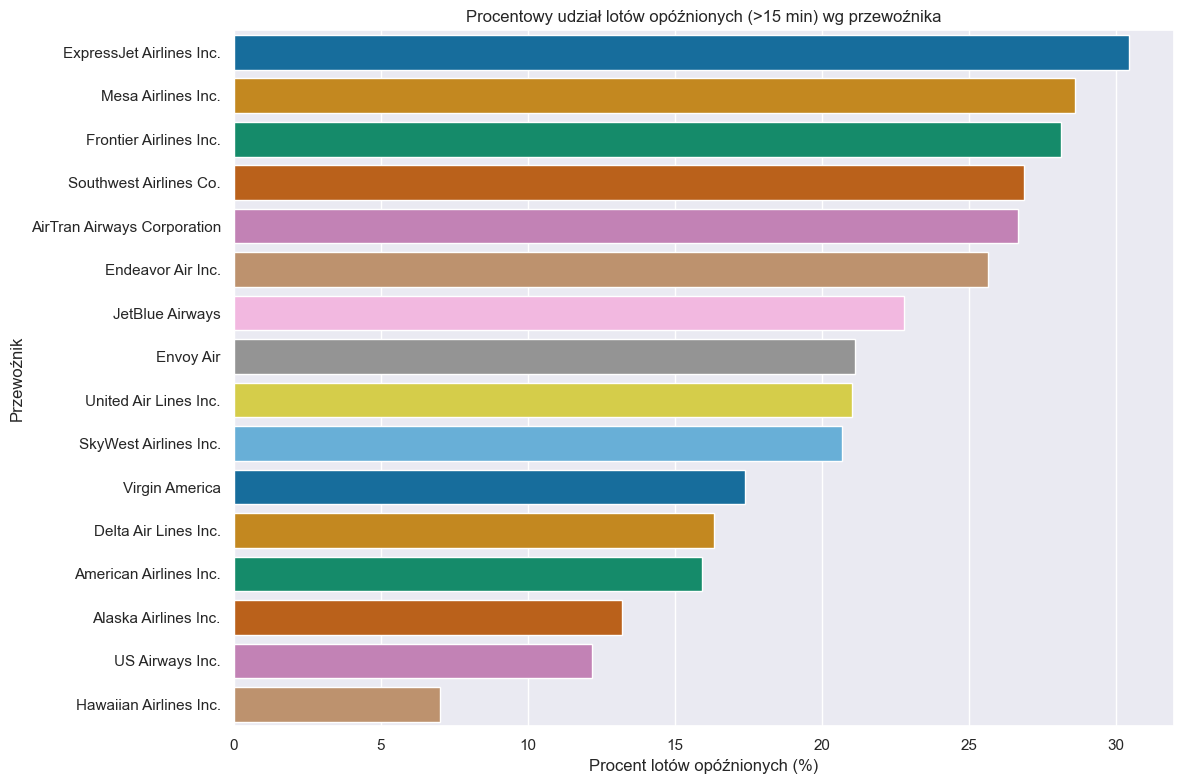

In [27]:

# Filtracja braków danych w kolumnie opóźnień
df = flights.dropna(subset=['dep_delay']).copy()
df = df.merge(airlines.drop_duplicates(subset=['carrier']), on='carrier', how='left')

# Utworzenie binarnej flagi opóźnienia (Powyżej 15 minut)
df['czy_opozniony'] = df['dep_delay'] > 15


procent_opoznien = df.groupby('name')['czy_opozniony'].mean() * 100
procent_opoznien = procent_opoznien.reset_index().sort_values(by='czy_opozniony', ascending=False)
procent_opoznien.columns = ['Linia lotnicza', 'Procent opóźnień (%)']


plt.figure(figsize=(12, 8))
sns.barplot(
    data=procent_opoznien,
    x='Procent opóźnień (%)',
    y='Linia lotnicza',
    hue='Linia lotnicza',
    palette='colorblind',
    legend=False
)
plt.title("Procentowy udział lotów opóźnionych (>15 min) wg przewoźnika")
plt.xlabel("Procent lotów opóźnionych (%)")
plt.ylabel("Przewoźnik")
plt.tight_layout()
plt.show()

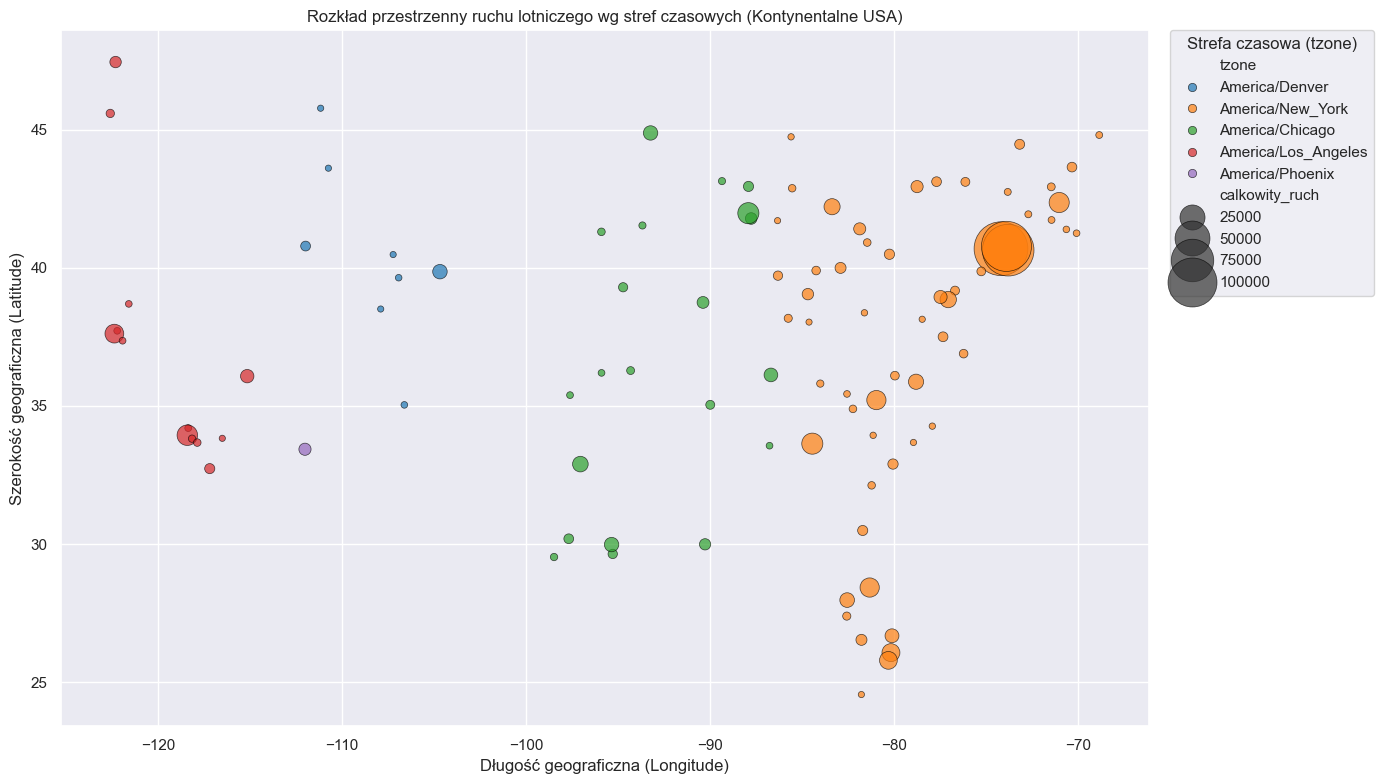

In [26]:


#  Agregacja ruchu lotniczego
odloty = flights['origin'].value_counts().reset_index()
odloty.columns = ['faa', 'liczba_odlotow']

przyloty = flights['dest'].value_counts().reset_index()
przyloty.columns = ['faa', 'liczba_przylotow']

#  Konsolidacja danych ze współrzędnymi i strefą czasową

baza_mapy = airports[['faa', 'name', 'lat', 'lon', 'tzone']].copy()
baza_mapy = baza_mapy.merge(odloty, on='faa', how='left').fillna({'liczba_odlotow': 0})
baza_mapy = baza_mapy.merge(przyloty, on='faa', how='left').fillna({'liczba_przylotow': 0})

baza_mapy['calkowity_ruch'] = baza_mapy['liczba_odlotow'] + baza_mapy['liczba_przylotow']
baza_mapy = baza_mapy[baza_mapy['calkowity_ruch'] > 0]

# Odcięcie Alaski i Hawajów
baza_mapy = baza_mapy[(baza_mapy['lon'] > -130) & (baza_mapy['lon'] < -60) & (baza_mapy['lat'] > 20) & (baza_mapy['lat'] < 50)]


plt.figure(figsize=(14, 8))
sns.set_theme(style="darkgrid")


sns.scatterplot(
    data=baza_mapy,
    x='lon',
    y='lat',
    size='calkowity_ruch',
    hue='tzone',
    sizes=(20, 1500),
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5,
    palette='tab10'
)

plt.title("Rozkład przestrzenny ruchu lotniczego wg stref czasowych (Kontynentalne USA)")
plt.xlabel("Długość geograficzna (Longitude)")
plt.ylabel("Szerokość geograficzna (Latitude)")


plt.legend(
    title='Strefa czasowa (tzone)',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

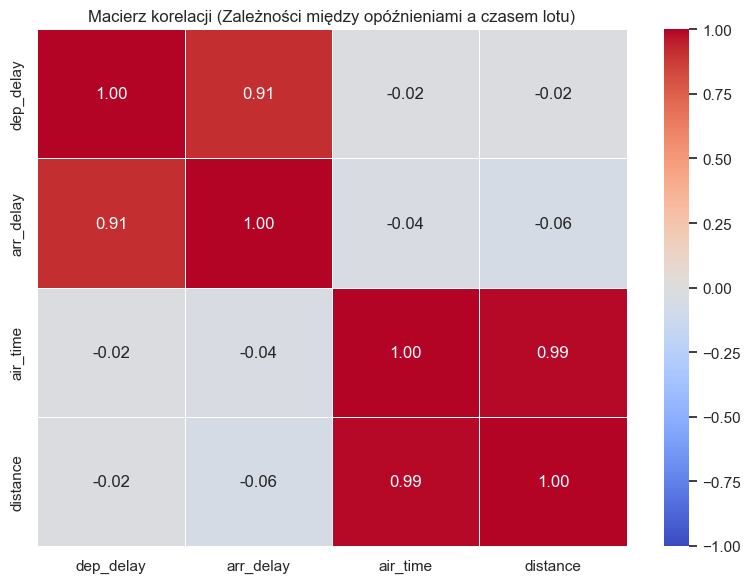

In [29]:
kolumny_numeryczne = ['dep_delay', 'arr_delay', 'air_time', 'distance']
df_num = flights[kolumny_numeryczne]

macierz_korelacji = df_num.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    macierz_korelacji,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title("Macierz korelacji (Zależności między opóźnieniami a czasem lotu)")
plt.tight_layout()
plt.show()